In [1]:
import os
import random
import time
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
import torchvision.models as models
from torchvision.models import ResNet50_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed:", SEED)

Random seed: 42


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!wget -q -O /content/plantvillage.zip \
https://www.kaggle.com/api/v1/datasets/download/abdallahalidev/plantvillage-dataset

In [6]:
import os

print(
    "ZIP exists:",
    os.path.exists("/content/plantvillage.zip")
)

print(
    "ZIP size:",
    round(
        os.path.getsize("/content/plantvillage.zip") / (1024**3),
        2
    ),
    "GB"
)

ZIP exists: True
ZIP size: 2.04 GB


In [7]:
import zipfile

EXTRACT_DIR = "/content/plantvillage"

os.makedirs(
    EXTRACT_DIR,
    exist_ok=True
)

if not os.path.exists(
    "/content/plantvillage/plantvillage dataset"
):

    with zipfile.ZipFile(
        "/content/plantvillage.zip",
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            EXTRACT_DIR
        )

    print("Dataset extracted successfully.")

else:
    print("Dataset already extracted.")

Dataset extracted successfully.


In [8]:
DATASET_ROOT = "/content/plantvillage/plantvillage dataset"

COLOR_DIR = os.path.join(
    DATASET_ROOT,
    "color"
)

print("Dataset root:")
print(DATASET_ROOT)

print("\nColor directory:")
print(COLOR_DIR)

print(
    "\nExists:",
    os.path.exists(COLOR_DIR)
)

Dataset root:
/content/plantvillage/plantvillage dataset

Color directory:
/content/plantvillage/plantvillage dataset/color

Exists: True


In [9]:
class_names = sorted([
    d
    for d in os.listdir(COLOR_DIR)
    if os.path.isdir(
        os.path.join(
            COLOR_DIR,
            d
        )
    )
])

print(
    "Number of classes:",
    len(class_names)
)

for i, class_name in enumerate(class_names):

    print(
        i,
        ":",
        class_name
    )

Number of classes: 38
0 : Apple___Apple_scab
1 : Apple___Black_rot
2 : Apple___Cedar_apple_rust
3 : Apple___healthy
4 : Blueberry___healthy
5 : Cherry_(including_sour)___Powdery_mildew
6 : Cherry_(including_sour)___healthy
7 : Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 : Corn_(maize)___Common_rust_
9 : Corn_(maize)___Northern_Leaf_Blight
10 : Corn_(maize)___healthy
11 : Grape___Black_rot
12 : Grape___Esca_(Black_Measles)
13 : Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 : Grape___healthy
15 : Orange___Haunglongbing_(Citrus_greening)
16 : Peach___Bacterial_spot
17 : Peach___healthy
18 : Pepper,_bell___Bacterial_spot
19 : Pepper,_bell___healthy
20 : Potato___Early_blight
21 : Potato___Late_blight
22 : Potato___healthy
23 : Raspberry___healthy
24 : Soybean___healthy
25 : Squash___Powdery_mildew
26 : Strawberry___Leaf_scorch
27 : Strawberry___healthy
28 : Tomato___Bacterial_spot
29 : Tomato___Early_blight
30 : Tomato___Late_blight
31 : Tomato___Leaf_Mold
32 : Tomato___Septoria_l

In [10]:
image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".JPG",
    ".JPEG",
    ".PNG"
)

data = []

for class_name in class_names:

    class_dir = os.path.join(
        COLOR_DIR,
        class_name
    )

    for filename in os.listdir(class_dir):

        if filename.endswith(
            image_extensions
        ):

            filepath = os.path.join(
                class_dir,
                filename
            )

            data.append({
                "filepath": filepath,
                "class_name": class_name
            })

df = pd.DataFrame(data)

print(
    "Total images:",
    len(df)
)

print(
    "Total classes:",
    df["class_name"].nunique()
)

df.head()

Total images: 54305
Total classes: 38


,filepath,class_name
0,/content/plantvillage/plantvillage dataset/col...,Apple___Apple_scab
1,/content/plantvillage/plantvillage dataset/col...,Apple___Apple_scab
2,/content/plantvillage/plantvillage dataset/col...,Apple___Apple_scab
3,/content/plantvillage/plantvillage dataset/col...,Apple___Apple_scab
4,/content/plantvillage/plantvillage dataset/col...,Apple___Apple_scab


In [11]:
class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

df["label"] = df[
    "class_name"
].map(class_to_idx)

print(df.head())

                                            filepath          class_name  \
0  /content/plantvillage/plantvillage dataset/col...  Apple___Apple_scab   
1  /content/plantvillage/plantvillage dataset/col...  Apple___Apple_scab   
2  /content/plantvillage/plantvillage dataset/col...  Apple___Apple_scab   
3  /content/plantvillage/plantvillage dataset/col...  Apple___Apple_scab   
4  /content/plantvillage/plantvillage dataset/col...  Apple___Apple_scab   

   label  
0      0  
1      0  
2      0  
3      0  
4      0  


In [12]:
class_counts = (
    df["class_name"]
    .value_counts()
    .sort_index()
)

print(class_counts)

class_name
Apple___Apple_scab                                     630
Apple___Black_rot                                      621
Apple___Cedar_apple_rust                               275
Apple___healthy                                       1645
Blueberry___healthy                                   1502
Cherry_(including_sour)___Powdery_mildew              1052
Cherry_(including_sour)___healthy                      854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     513
Corn_(maize)___Common_rust_                           1192
Corn_(maize)___Northern_Leaf_Blight                    985
Corn_(maize)___healthy                                1162
Grape___Black_rot                                     1180
Grape___Esca_(Black_Measles)                          1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)            1076
Grape___healthy                                        423
Orange___Haunglongbing_(Citrus_greening)              5507
Peach___Bacterial_spot                       

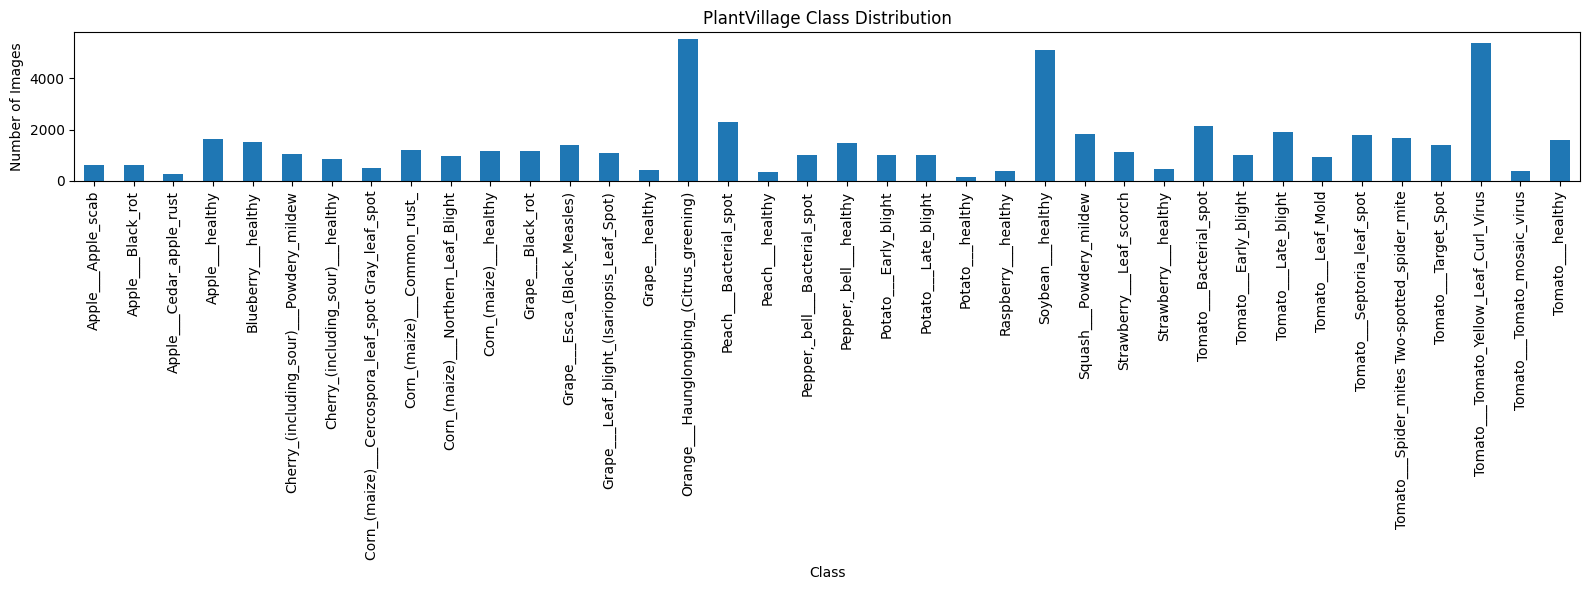

In [13]:
plt.figure(figsize=(16, 6))

class_counts.plot(
    kind="bar"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title(
    "PlantVillage Class Distribution"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()
plt.show()

In [14]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(
    drop=True
)

val_df = val_df.reset_index(
    drop=True
)

test_df = test_df.reset_index(
    drop=True
)

print(
    "Training images:",
    len(train_df)
)

print(
    "Validation images:",
    len(val_df)
)

print(
    "Testing images:",
    len(test_df)
)

print("\nPercentages:")

print(
    "Train:",
    len(train_df) / len(df) * 100
)

print(
    "Validation:",
    len(val_df) / len(df) * 100
)

print(
    "Test:",
    len(test_df) / len(df) * 100
)

Training images: 38013
Validation images: 8146
Testing images: 8146

Percentages:
Train: 69.99907927446827
Validation: 15.00046036276586
Test: 15.00046036276586


In [15]:
train_paths = set(
    train_df["filepath"]
)

val_paths = set(
    val_df["filepath"]
)

test_paths = set(
    test_df["filepath"]
)

print(
    "Train ∩ Validation:",
    len(train_paths & val_paths)
)

print(
    "Train ∩ Test:",
    len(train_paths & test_paths)
)

print(
    "Validation ∩ Test:",
    len(val_paths & test_paths)
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [16]:
PROJECT_DIR = (
    "/content/drive/MyDrive/"
    "PlantDisease_ResNet"
)

os.makedirs(
    PROJECT_DIR,
    exist_ok=True
)

SPLIT_DIR = os.path.join(
    PROJECT_DIR,
    "Splits"
)

os.makedirs(
    SPLIT_DIR,
    exist_ok=True
)

TRAIN_CSV = os.path.join(
    SPLIT_DIR,
    "train_split.csv"
)

VAL_CSV = os.path.join(
    SPLIT_DIR,
    "val_split.csv"
)

TEST_CSV = os.path.join(
    SPLIT_DIR,
    "test_split.csv"
)

train_df.to_csv(
    TRAIN_CSV,
    index=False
)

val_df.to_csv(
    VAL_CSV,
    index=False
)

test_df.to_csv(
    TEST_CSV,
    index=False
)

print("Split files saved.")

print(TRAIN_CSV)
print(VAL_CSV)
print(TEST_CSV)

Split files saved.
/content/drive/MyDrive/PlantDisease_ResNet/Splits/train_split.csv
/content/drive/MyDrive/PlantDisease_ResNet/Splits/val_split.csv
/content/drive/MyDrive/PlantDisease_ResNet/Splits/test_split.csv


In [17]:
IMAGE_SIZE = 224

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        10
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


val_test_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Transforms created.")

Transforms created.


In [18]:
class PlantVillageDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(
            self.dataframe
        )

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["filepath"]

        label = int(
            row["label"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:

            image = self.transform(
                image
            )

        return image, label

In [19]:
train_dataset = PlantVillageDataset(
    train_df,
    train_transform
)

val_dataset = PlantVillageDataset(
    val_df,
    val_test_transform
)

test_dataset = PlantVillageDataset(
    test_df,
    val_test_transform
)

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)

Train: 38013
Validation: 8146
Test: 8146


In [20]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders ready.")

DataLoaders ready.


In [21]:
images, labels = next(
    iter(train_loader)
)

print(
    "Image batch shape:",
    images.shape
)

print(
    "Label batch shape:",
    labels.shape
)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


In [22]:
weights = ResNet50_Weights.DEFAULT

model = models.resnet50(
    weights=weights
)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 83.7MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [23]:
NUM_CLASSES = 38

num_features = model.fc.in_features

model.fc = nn.Sequential(

    nn.Dropout(
        p=0.5
    ),

    nn.Linear(
        num_features,
        NUM_CLASSES
    )
)

model = model.to(device)

print(model.fc)

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=38, bias=True)
)


In [24]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Loss, optimizer and scheduler created.")

Loss, optimizer and scheduler created.


In [25]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss / total
    )

    epoch_acc = (
        correct / total
    ) * 100

    return epoch_loss, epoch_acc

In [26]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item()
                * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predicted.cpu().numpy()
            )

    epoch_loss = (
        running_loss / total
    )

    epoch_acc = (
        correct / total
    ) * 100

    return (
        epoch_loss,
        epoch_acc,
        all_labels,
        all_predictions
    )

In [27]:
EPOCHS = 15

best_val_acc = 0.0

best_model_wts = copy.deepcopy(
    model.state_dict()
)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_path = os.path.join(
    PROJECT_DIR,
    "best_resnet50.pth"
)

for epoch in range(EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, _, _ = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(
        val_acc
    )

    history["train_loss"].append(
        train_loss
    )

    history["train_acc"].append(
        train_acc
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_acc"].append(
        val_acc
    )

    current_lr = optimizer.param_groups[0]["lr"]

    elapsed = (
        time.time() - start_time
    ) / 60

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}%"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    print(
        f"Learning Rate: {current_lr:.6f}"
    )

    print(
        f"Time: {elapsed:.2f} minutes"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_model_wts = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_acc
            },
            best_model_path
        )

        print("✓ Best model saved!")

print(
    "\nBest validation accuracy:",
    f"{best_val_acc:.2f}%"
)


Epoch 1/15
Train Loss: 0.3739 | Train Acc: 90.25%
Val Loss: 0.0385 | Val Acc: 98.83%
Learning Rate: 0.000100
Time: 7.26 minutes
✓ Best model saved!

Epoch 2/15
Train Loss: 0.0508 | Train Acc: 98.47%
Val Loss: 0.0329 | Val Acc: 99.10%
Learning Rate: 0.000100
Time: 7.32 minutes
✓ Best model saved!

Epoch 3/15
Train Loss: 0.0343 | Train Acc: 98.98%
Val Loss: 0.0192 | Val Acc: 99.44%
Learning Rate: 0.000100
Time: 7.38 minutes
✓ Best model saved!

Epoch 4/15
Train Loss: 0.0303 | Train Acc: 99.06%
Val Loss: 0.0161 | Val Acc: 99.56%
Learning Rate: 0.000100
Time: 7.56 minutes
✓ Best model saved!

Epoch 5/15
Train Loss: 0.0235 | Train Acc: 99.29%
Val Loss: 0.0161 | Val Acc: 99.51%
Learning Rate: 0.000100
Time: 7.47 minutes

Epoch 6/15
Train Loss: 0.0204 | Train Acc: 99.38%
Val Loss: 0.0150 | Val Acc: 99.59%
Learning Rate: 0.000100
Time: 7.36 minutes
✓ Best model saved!

Epoch 7/15
Train Loss: 0.0174 | Train Acc: 99.43%
Val Loss: 0.0147 | Val Acc: 99.56%
Learning Rate: 0.000100
Time: 7.37 minut

In [28]:
checkpoint = torch.load(
    best_model_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    "Best model loaded."
)

print(
    "Best validation accuracy:",
    checkpoint["val_accuracy"]
)

Best model loaded.
Best validation accuracy: 99.7176528357476


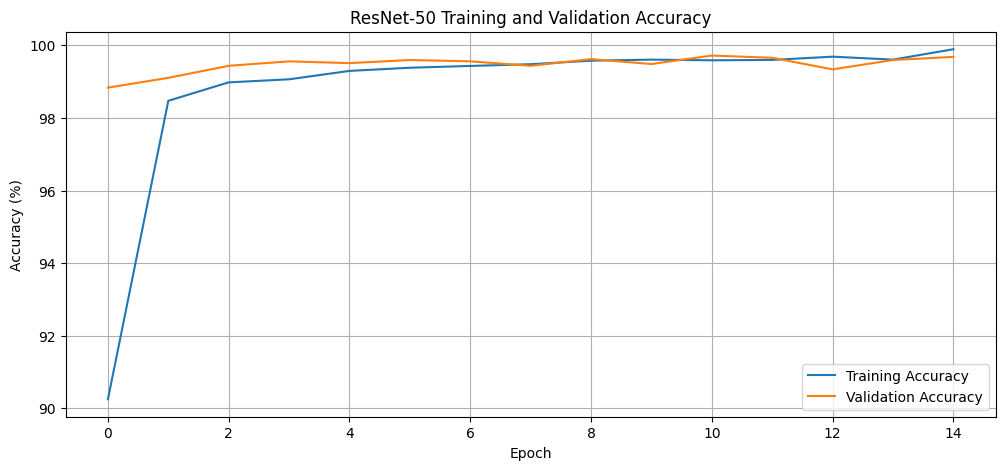

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(
    history["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "ResNet-50 Training and Validation Accuracy"
)

plt.legend()

plt.grid()

plt.show()

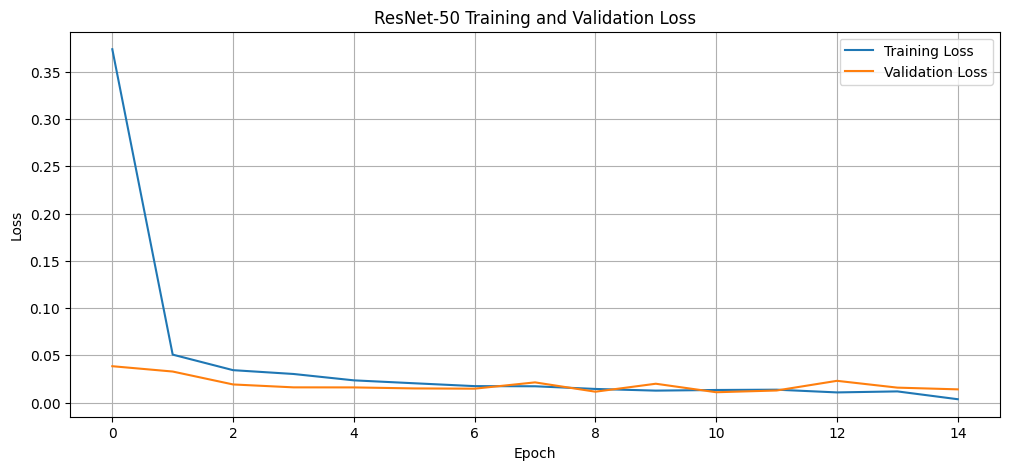

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ResNet-50 Training and Validation Loss"
)

plt.legend()

plt.grid()

plt.show()

In [32]:
test_loss, test_acc, test_labels, test_predictions = validate(
    model,
    test_loader,
    criterion,
    device
)

print(
    "Test Loss:",
    f"{test_loss:.4f}"
)

print(
    "Test Accuracy:",
    f"{test_acc:.2f}%"
)

Test Loss: 0.0117
Test Accuracy: 99.69%


In [33]:
precision = precision_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

print(
    f"Accuracy  : {test_acc:.2f}%"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"Weighted F1: {f1:.4f}"
)

print(
    f"Macro F1  : {macro_f1:.4f}"
)

Accuracy  : 99.69%
Precision : 0.9970
Recall    : 0.9969
Weighted F1: 0.9969
Macro F1  : 0.9956


In [34]:
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9894    0.9947        94
                                 Apple___Black_rot     1.0000    1.0000    1.0000        93
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        41
                                   Apple___healthy     0.9960    1.0000    0.9980       246
                               Blueberry___healthy     1.0000    1.0000    1.0000       226
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       158
                 Cherry_(including_sour)___healthy     1.0000    1.0000    1.0000       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9136    0.9610    0.9367        77
                       Corn_(maize)___Common_rust_     1.0000    0.9944    0.9972       179
               Corn_(maize)___Northern_Leaf_Blight     0.9792    0.9592    0.96

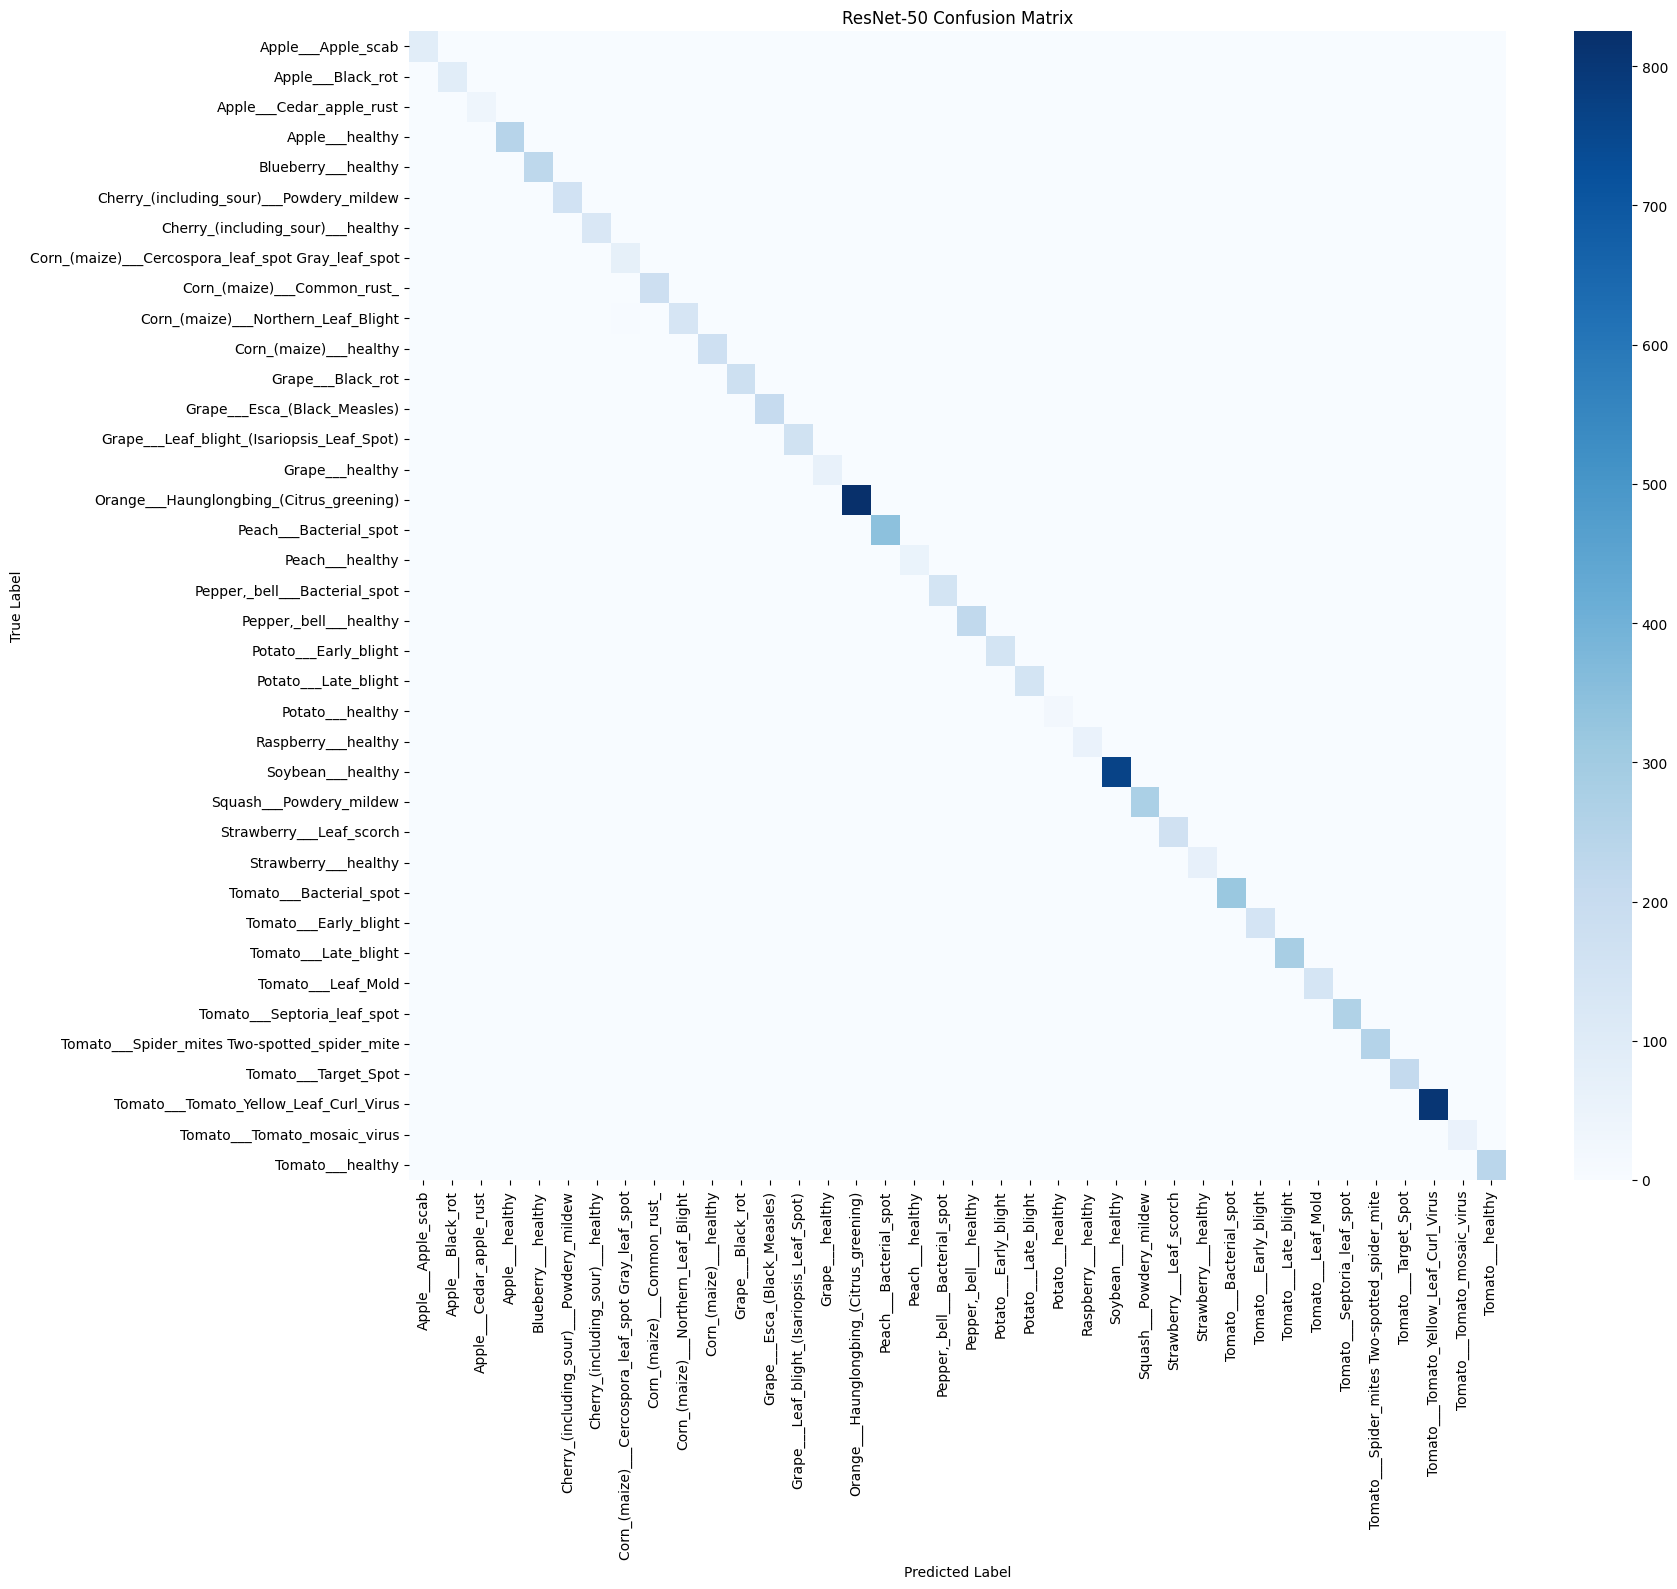

In [35]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(
    figsize=(18, 16)
)

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "ResNet-50 Confusion Matrix"
)

plt.xticks(
    rotation=90
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [36]:
def get_test_probabilities(
    model,
    loader,
    device
):

    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            outputs = model(
                images
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            all_labels.extend(
                labels.numpy()
            )

            all_probs.extend(
                probabilities.cpu().numpy()
            )

    return (
        np.array(all_labels),
        np.array(all_probs)
    )

In [37]:
roc_labels, roc_probs = get_test_probabilities(
    model,
    test_loader,
    device
)

y_true_binary = label_binarize(
    roc_labels,
    classes=np.arange(NUM_CLASSES)
)

roc_auc = roc_auc_score(
    y_true_binary,
    roc_probs,
    multi_class="ovr",
    average="weighted"
)

print(
    "Weighted Multiclass ROC-AUC:",
    f"{roc_auc:.4f}"
)

Weighted Multiclass ROC-AUC: 1.0000


In [38]:
results = pd.DataFrame({
    "Model": [
        "ResNet-50"
    ],

    "Test Accuracy": [
        test_acc
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "Weighted F1": [
        f1
    ],

    "Macro F1": [
        macro_f1
    ],

    "ROC-AUC": [
        roc_auc
    ]
})

results

,Model,Test Accuracy,Precision,Recall,Weighted F1,Macro F1,ROC-AUC
0,ResNet-50,99.693101,0.996988,0.996931,0.996944,0.995585,0.999992


In [39]:
results.to_csv(
    os.path.join(
        PROJECT_DIR,
        "resnet50_results.csv"
    ),
    index=False
)

print("Results saved.")

Results saved.


In [40]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [41]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [42]:
target_layers = [
    model.layer4[-1].conv3
]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [43]:
def generate_gradcam(
    model,
    image_path,
    class_names,
    target_layers,
    device
):

    model.eval()

    # Load image
    image = Image.open(
        image_path
    ).convert("RGB")

    # Original image for visualization
    original_image = image.resize(
        (224, 224)
    )

    rgb_image = np.array(
        original_image
    ).astype(np.float32) / 255.0

    # Preprocess
    input_tensor = val_test_transform(
        image
    ).unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():

        output = model(
            input_tensor
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_class = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = probabilities[
            0,
            predicted_class
        ].item()

    # Target class
    targets = [
        ClassifierOutputTarget(
            predicted_class
        )
    ]

    # Generate CAM
    with GradCAM(
        model=model,
        target_layers=target_layers
    ) as cam:

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]

    # Overlay CAM
    visualization = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True
    )

    return (
        original_image,
        visualization,
        predicted_class,
        confidence
    )

In [44]:
sample_image = test_df.iloc[0]["filepath"]

(
    original,
    gradcam_image,
    predicted_class,
    confidence
) = generate_gradcam(
    model,
    sample_image,
    class_names,
    target_layers,
    device
)

print(
    "Predicted class:",
    class_names[predicted_class]
)

print(
    "Confidence:",
    f"{confidence * 100:.2f}%"
)

Predicted class: Tomato___Late_blight
Confidence: 100.00%


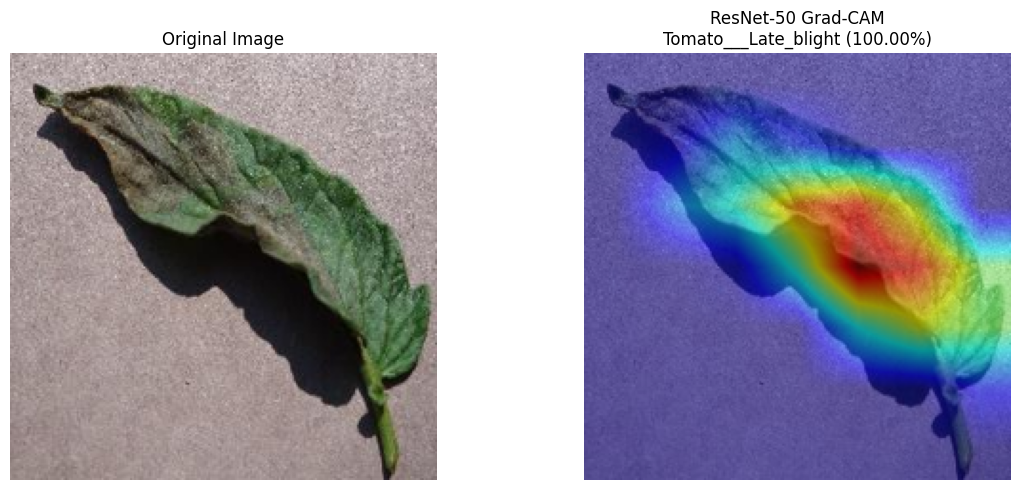

In [45]:
plt.figure(
    figsize=(12, 5)
)

plt.subplot(
    1, 2, 1
)

plt.imshow(original)

plt.title(
    "Original Image"
)

plt.axis("off")


plt.subplot(
    1, 2, 2
)

plt.imshow(gradcam_image)

plt.title(
    f"ResNet-50 Grad-CAM\n"
    f"{class_names[predicted_class]} "
    f"({confidence * 100:.2f}%)"
)

plt.axis("off")

plt.tight_layout()

plt.show()

In [46]:
!pip install -q -U transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 18.3 MB/s eta 0:00:00


In [47]:
import torch
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)

VLM_MODEL = "Qwen/Qwen2.5-VL-3B-Instruct"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

vlm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    VLM_MODEL,
    quantization_config=quant_config,
    device_map="auto"
)

vlm_processor = AutoProcessor.from_pretrained(
    VLM_MODEL
)

print("VLM loaded successfully.")

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

VLM loaded successfully.


In [48]:
def resnet_predict(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = test_transform(
        image
    ).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(
            image_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predicted_class = torch.max(
            probabilities,
            dim=1
        )

    predicted_label = class_names[
        predicted_class.item()
    ]

    confidence_value = confidence.item() * 100

    return (
        predicted_label,
        confidence_value
    )

In [49]:
def generate_vlm_explanation(
    image_path,
    predicted_label,
    confidence
):

    prompt = f"""
You are an agricultural plant disease analysis assistant.

A ResNet-50 classifier predicted:

Disease: {predicted_label}
Confidence: {confidence:.2f}%

Analyze the provided plant leaf image and give a concise explanation.

Your response must contain:

1. Predicted disease
2. Visible symptoms in the leaf
3. Visual evidence supporting the prediction
4. Possible cause
5. Recommended management or prevention
6. A short warning that this is an AI-based prediction and should be verified by an agricultural expert.

Do not invent symptoms that are not reasonably visible in the image.
"""

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    text = vlm_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = vlm_processor(
        text=[text],
        images=[Image.open(image_path).convert("RGB")],
        padding=True,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(vlm_model.device)
        if hasattr(v, "to")
        else v
        for k, v in inputs.items()
    }

    with torch.no_grad():

        generated_ids = vlm_model.generate(
            **inputs,
            max_new_tokens=300,
            do_sample=False
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids
        in zip(
            inputs["input_ids"],
            generated_ids
        )
    ]

    output_text = vlm_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return output_text

In [50]:
def resnet_vlm_pipeline(image_path):

    # -------------------------
    # Step 1: ResNet prediction
    # -------------------------

    predicted_label, confidence = resnet_predict(
        image_path
    )

    print("=" * 60)
    print("RESNET-50 PREDICTION")
    print("=" * 60)

    print(
        f"Disease    : {predicted_label}"
    )

    print(
        f"Confidence : {confidence:.2f}%"
    )

    # -------------------------
    # Step 2: VLM explanation
    # -------------------------

    print("\n")
    print("=" * 60)
    print("VLM EXPLANATION")
    print("=" * 60)

    explanation = generate_vlm_explanation(
        image_path,
        predicted_label,
        confidence
    )

    print(explanation)

    return {
        "disease": predicted_label,
        "confidence": confidence,
        "explanation": explanation
    }

In [51]:
def resnet_vlm_pipeline(image_path):

    # -------------------------
    # Step 1: ResNet prediction
    # -------------------------

    predicted_label, confidence = resnet_predict(
        image_path
    )

    print("=" * 60)
    print("RESNET-50 PREDICTION")
    print("=" * 60)

    print(
        f"Disease    : {predicted_label}"
    )

    print(
        f"Confidence : {confidence:.2f}%"
    )

    # -------------------------
    # Step 2: VLM explanation
    # -------------------------

    print("\n")
    print("=" * 60)
    print("VLM EXPLANATION")
    print("=" * 60)

    explanation = generate_vlm_explanation(
        image_path,
        predicted_label,
        confidence
    )

    print(explanation)

    return {
        "disease": predicted_label,
        "confidence": confidence,
        "explanation": explanation
    }

In [52]:
print("VLM test started")

print("Model:", type(vlm_model))
print("Processor:", type(vlm_processor))

print("VLM device:")
print(next(vlm_model.parameters()).device)

print("VLM loaded successfully!")

VLM test started
Model: <class 'transformers.models.qwen2_5_vl.modeling_qwen2_5_vl.Qwen2_5_VLForConditionalGeneration'>
Processor: <class 'transformers.models.qwen2_5_vl.processing_qwen2_5_vl.Qwen2_5_VLProcessor'>
VLM device:
cuda:0
VLM loaded successfully!


Image loaded successfully
Image size: (256, 256)


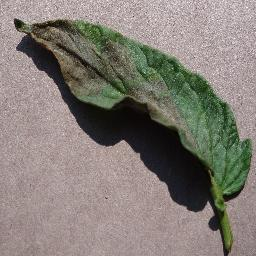

In [57]:
from PIL import Image
from IPython.display import display

image = Image.open(image_path).convert("RGB")

print("Image loaded successfully")
print("Image size:", image.size)

display(image)

In [58]:
prompt = """
Analyze this plant leaf image.

The ResNet-50 classifier predicted:
Disease: Tomato___Late_blight
Confidence: 100%

Explain the prediction based on the visible features in the image.

Give your response in this format:

Disease:
Visible symptoms:
Visual evidence:
Possible cause:
Recommended management:
AI limitation:
"""

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt}
        ]
    }
]

text = vlm_processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = vlm_processor(
    text=[text],
    images=[image],
    padding=True,
    return_tensors="pt"
)

inputs = {
    k: v.to(vlm_model.device)
    if hasattr(v, "to") else v
    for k, v in inputs.items()
}

print("Generating VLM response...")

with torch.no_grad():
    generated_ids = vlm_model.generate(
        **inputs,
        max_new_tokens=300,
        do_sample=False
    )

generated_text = vlm_processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("\n========== VLM OUTPUT ==========\n")
print(generated_text)

Generating VLM response...


/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (3420) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(



========== VLM OUTPUT ==========

system
You are a helpful assistant.
user

Analyze this plant leaf image.

The ResNet-50 classifier predicted:
Disease: Tomato___Late_blight
Confidence: 100%

Explain the prediction based on the visible features in the image.

Give your response in this format:

Disease:
Visible symptoms:
Visual evidence:
Possible cause:
Recommended management:
AI limitation:

assistant
Disease: Tomato Late Blight

Visible symptoms:
- The leaf has dark, brownish spots and discoloration.
- The edges of the leaf appear to be curled or damaged.

Visual evidence:
- The leaf shows signs of infection with dark, irregular patches that are characteristic of late blight.
- The leaf's texture appears rough due to the disease.

Possible cause:
- Late blight is caused by the fungus Phytophthora infestans, which thrives in wet conditions and can infect tomato plants.

Recommended management:
- Remove and destroy infected leaves to prevent spread.
- Use fungicides specifically desig

Image path:
/content/plantvillage/plantvillage dataset/color/Tomato___Late_blight/467da834-4482-4233-90d1-03bc4dc60966___RS_Late.B 5136.JPG
Image loaded successfully
Image size: (256, 256)


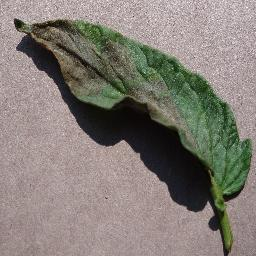

In [53]:
image_path = test_df.iloc[0]["filepath"]

print("Image path:")
print(image_path)

image = Image.open(image_path).convert("RGB")

print("Image loaded successfully")
print("Image size:", image.size)

display(image)

In [55]:
from torchvision import transforms

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("test_transform defined successfully!")

test_transform defined successfully!


In [56]:
predicted_label, confidence = resnet_predict(
    image_path
)

print("ResNet prediction:")
print("Disease:", predicted_label)
print("Confidence:", f"{confidence:.2f}%")

ResNet prediction:
Disease: Tomato___Late_blight
Confidence: 100.00%
